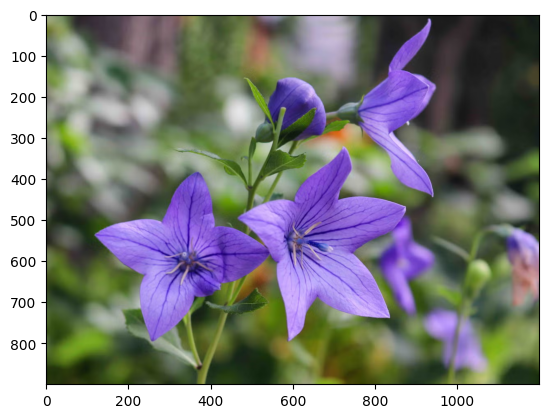

In [4]:
from skimage.feature import hog
from skimage import exposure
import cv2
import matplotlib.pyplot as plt

path = '/content/gettyimages-2165950545-69600af8c9b0d.jpg.avif'
image = cv2.imread(path)
image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.show()


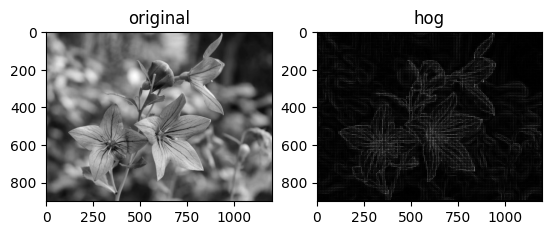

hog feature vector
[0.3175805  0.02631056 0.0832013  ... 0.21428093 0.         0.        ]


In [8]:
# historam of oriented gradietns

gray = cv2.cvtColor(image_rgb , cv2.COLOR_RGB2GRAY)

features, hog_image = hog(gray, pixels_per_cell=(8,8) , cells_per_block=(2,2), visualize=True)

hog_image_rescale = exposure.rescale_intensity(hog_image,in_range=(0,10))

plt.subplot(1,2,1)
plt.imshow(gray, cmap=plt.cm.gray)
plt.title('original')

plt.subplot(1,2,2)
plt.imshow(hog_image_rescale , cmap=plt.cm.gray)
plt.title('hog')
plt.show()

print("hog feature vector")
print(features)


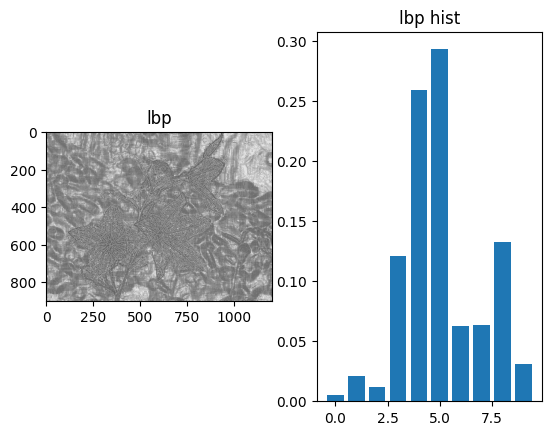

lbp feature vect
[0.00538519 0.02085833 0.01156111 0.12093796 0.25912685 0.29288241
 0.06242963 0.06306852 0.13249259 0.03125741]


In [9]:
# local binary pattern

from skimage import feature
import numpy as np

radius = 1
n_points = 8*radius

lbp_image = feature.local_binary_pattern(gray , n_points , radius, method='uniform')

hist , _ = np.histogram(lbp_image.ravel(), bins=np.arange(0,n_points+3) , range=(0,n_points+2))

hist = hist.astype('float')
hist /= (hist.sum() + 1e-6)


plt.subplot(1,2,1)
plt.imshow(lbp_image, cmap='gray')
plt.title('lbp')

plt.subplot(1,2,2)
plt.bar(range(0,n_points+2),hist)
plt.title('lbp hist')
plt.show()

print('lbp feature vect')
print(hist)

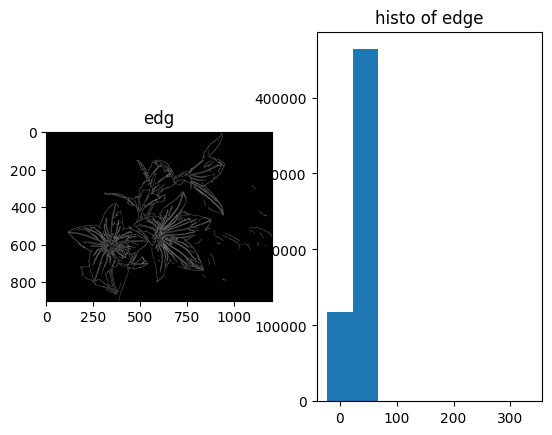

In [10]:
# histogram of edge directions

smooth_img = cv2.GaussianBlur(gray, (5,5) ,0)

edges = cv2.Canny(smooth_img,  threshold1=30, threshold2=70)

gradient_x = cv2.Sobel(smooth_img , cv2.CV_64F , 1,0,ksize=3)
gradient_y = cv2.Sobel(smooth_img , cv2.CV_64F , 0,1,ksize=3)
grad_magnitude = np.sqrt(gradient_x**2 +gradient_y**2)
grad_orientation= np.arctan(gradient_y , gradient_x) * 180 / np.pi

hist,bin_edges = np.histogram(grad_orientation , bins=8 , range=(0,360))

plt.subplot(1,2,1)
plt.imshow(edges,cmap='gray')
plt.title('edg')

plt.subplot(1,2,2)
plt.bar(bin_edges[:-1],hist,width=45,align='center')
plt.title('histo of edge')

plt.show()

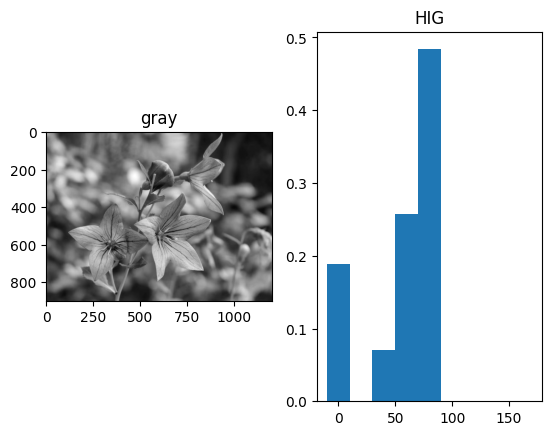

In [14]:
# histogram of intesnity gradients

dx = cv2.Sobel(gray , cv2.CV_64F , 1 , 0 , ksize=3)
dy = cv2.Sobel(gray , cv2.CV_64F , 0 , 1 , ksize=3)

magnitude = np.sqrt(dx**2 + dy**2)
orientation = np.arctan(dy,dx)*(180/np.pi)

histogram , bins = np.histogram(orientation , bins=9 , range=(0,180))
histogram = histogram / histogram.sum()



plt.subplot(1,2,1)
plt.imshow(gray,cmap='gray')
plt.title('gray')

plt.subplot(1,2,2)
plt.bar(bins[:-1],histogram,width=20)
plt.title("HIG")
plt.show()

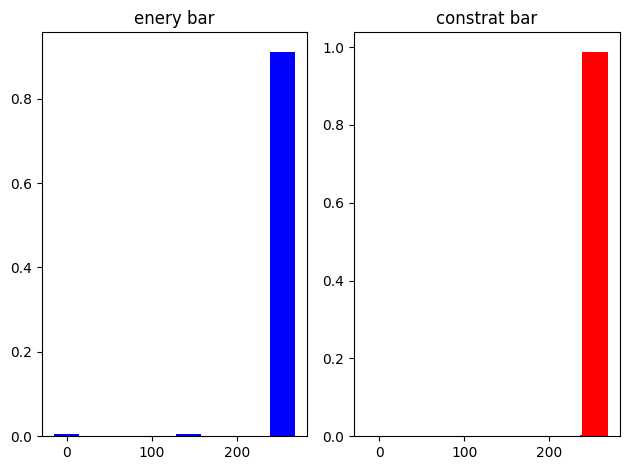

In [21]:
# texture energy and contrast histograms

neighborhood_size = 3

energy = cv2.filter2D(gray**2 , -1, np.ones((neighborhood_size,neighborhood_size)))
contrast = cv2.filter2D(gray, -1, np.ones((neighborhood_size,neighborhood_size)))

energy_hist , energy_bins = np.histogram(energy , bins=256 , range=(0,energy.max()))
contrast_hist , contrast_bins = np.histogram(contrast , bins=256 , range=(0,contrast.max()))

energy_hist = energy_hist/energy_hist.sum()
contrast_hist = contrast_hist/ contrast_hist.sum()

plt.subplot(1,2,1)
plt.bar(energy_bins[:-1],energy_hist ,color='blue',width=30 )
plt.title("enery bar")

plt.subplot(1,2,2)
plt.bar(contrast_bins[:-1],contrast_hist ,color='r',width=30 )
plt.title("constrat bar")

plt.tight_layout()
plt.show()

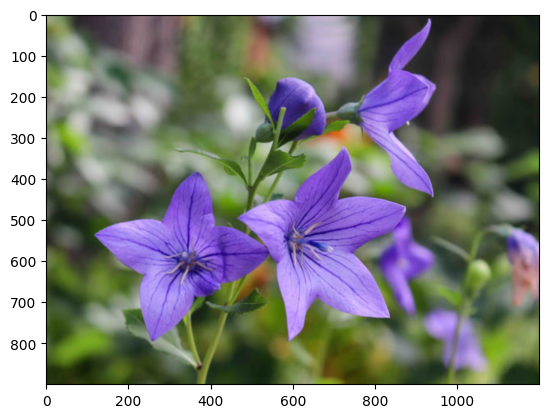

In [22]:
# box blur
image = cv2.imread(path)
image_rgb = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)

kernel = np.ones((3,3) , dtype=np.float32) / 9

blur_image = cv2.filter2D(image_rgb , -1, kernel)

plt.imshow(blur_image)
plt.show()

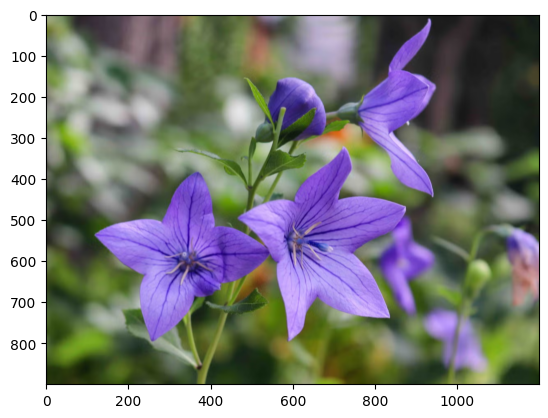

In [26]:
#gaussian blur

kernel_size = (5,5)
sigma= 1.0
kernel = cv2.getGaussianKernel(kernel_size[0],sigma)

gaussian_blur = cv2.filter2D(image_rgb, -1, kernel)

plt.imshow(gaussian_blur)
plt.show()

In [ ]:
# sibel edge detection

sobel_x = cv2.Sobel(image_rgb , cv2.CV_64F ,1 , 0 , ksize=3)
sobel_y = cv2.Sobel(image_rgb , cv2.CV_64F ,0 , 1 , ksize=3)

#scharr edge detection
scharr_x = cv2.Scharr(image_rgb , cv2.CV_64F ,1 , 0 )
scharr_y = cv2.Scharr(image_rgb , cv2.CV_64F ,0 , 1 )

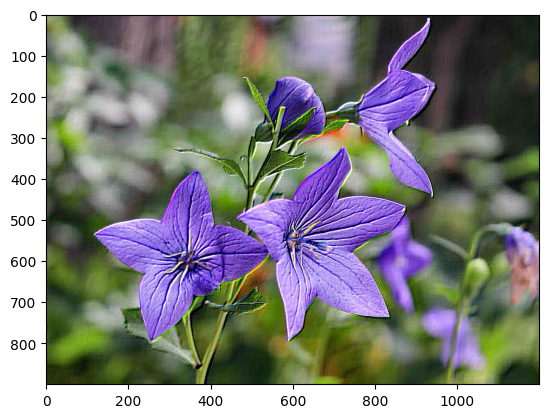

In [27]:
#embossing

kernel = np.array([[-2,-1,0],[-1,1,1],[0,1,2]] , dtype=np.float32)

embossed_img = cv2.filter2D(image_rgb,-1,kernel)
plt.imshow(embossed_img)
plt.show()